In [1]:
import sys
sys.path.append('../')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import joblib
import contextlib
import io

import torch
from dataset.data_classes import PytorchSpectraDataset
from dataset.dataset_builder import SpectralDatasetBuilder

from models.cdiff_lightning import LitCfgDiffusion
from models.cvae_lightning import LitVAE
from models.cbegan_lightning import SpectralCBEGAN
from utils.utils import encode_labels

from tools.Evaluator_FTIR import Evaluator_FTIR
from tools.Evaluator_Peak_Ratios import Evaluator_Peak_Ratios
from tools.Loss_Metric_Manager import Loss_Metric_Manager

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cdiff = LitCfgDiffusion.load_from_checkpoint("../pretrained_models/weights_cdiff.ckpt")
cdiff.to(device)
cdiff.eval();

In [3]:
dataset_builder = SpectralDatasetBuilder(data_path='../data/in-silico-gen-data.parquet', data_split={"train": 0.8, "test": 0.2}, config_path='../config.yaml')
dataset = PytorchSpectraDataset("../data/h4h_raw_2024-09-16_with_subject_ids.parquet")
column_names = dataset.df_test_scaled.iloc[:,:519].columns.values.astype(float)

y_real = dataset.df_test_normalized[['sex', 'bmi', 'age']]
bmi_age = y_real[['bmi', 'age']]
bmi_age = dataset_builder.minmax_scaler.inverse_transform(bmi_age).T
bmi = bmi_age[0]
age = bmi_age[1]
sex = y_real['sex'].map({0: 'male', 1:'female'}).values

y_df = pd.DataFrame({
    "sex": sex,
    "bmi": bmi,
    "age": age
})

In [4]:
y_real = y_real.iloc[:2]

num_samples = len(y_real)

labels_dict = {
    col: torch.tensor(y_real[col].values, device=device, dtype=torch.float32) 
    for col in ['sex', 'bmi', 'age']
}

y = encode_labels(labels_dict, 24, device)

# GIF

In [5]:
import torch
import matplotlib.pyplot as plt
import imageio
import io
 
# ── Shared config ──────────────────────────────────────────────────────────────
GUIDANCE_SCALE      = 1.5
PREDICTION_CLAMP    = None   # e.g. 1.0 to clamp x0 predictions, or None to disable
TIMESTEP_TRUNCATION = 3      # skip this many steps at the noisy end (0 = full chain)
 
# ── DDPM GIF ───────────────────────────────────────────────────────────────────
frames = []
 
with torch.no_grad(), cdiff.ema.average_parameters():
    gamma = GUIDANCE_SCALE
    B = len(y_real)
    x = torch.randn(B, cdiff.cdiff.input_features, device=cdiff.device)
 
    import numpy as np
    indices = np.array(list(reversed(range(len(cdiff.betas))))) - TIMESTEP_TRUNCATION
    indices = indices[indices >= 0]
 
    for t_idx in indices:
        t = torch.full((B,), t_idx, device=cdiff.device, dtype=torch.long)
 
        # CFG
        eps_cond   = cdiff.cdiff.forward(x, y, t)
        eps_uncond = cdiff.cdiff.forward_uncond(x, t)
        eps        = eps_uncond + gamma * (eps_cond - eps_uncond)
 
        # Diffusion parameters
        alpha        = cdiff.alphas[t_idx]
        alpha_b      = cdiff.alpha_bar[t_idx]
        alpha_b_prev = cdiff.alpha_bar_prev[t_idx]   # precomputed, matches sample_ddpm
        beta         = cdiff.betas[t_idx]
 
        x0_pred = (x - (1 - alpha_b).sqrt() * eps) / alpha_b.sqrt()
        if PREDICTION_CLAMP is not None:
            x0_pred = torch.clamp(x0_pred, -PREDICTION_CLAMP, PREDICTION_CLAMP)
 
        mean = (
            (alpha_b_prev.sqrt() * beta / (1 - alpha_b)) * x0_pred
            + (alpha.sqrt() * (1 - alpha_b_prev) / (1 - alpha_b)) * x
        )
 
        # ── Render frame ──────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(x.cpu().numpy()[0])
        ax.set_ylim([-3, 3])
        ax.set_xlabel("Wavenumber index")
        ax.set_ylabel("Normalized absorbance [a.u.]")
        ax.set_title(f"Reverse diffusion step t={t_idx}")
        fig.tight_layout()
 
        buf = io.BytesIO()
        plt.savefig(buf, format="png")
        buf.seek(0)
        frames.append(imageio.v2.imread(buf))
        plt.close(fig)
        # ──────────────────────────────────────────────────────────────────────
 
        if t_idx > 0:
            beta_tilde = beta * (1 - alpha_b_prev) / (1 - alpha_b)
            noise = torch.randn_like(x)
            x = mean + beta_tilde.sqrt() * noise
        else:
            x = mean
 
imageio.mimsave("ddpm_spectrum_generation.gif", frames, fps=10)
 
 
# ── DDIM GIF ───────────────────────────────────────────────────────────────────
frames = []
 
with torch.no_grad(), cdiff.ema.average_parameters():
    n_steps = 64
    eta     = 0.0
    gamma   = GUIDANCE_SCALE
    B       = len(y)
 
    # Build strided timestep subsequence
    total_T   = len(cdiff.betas)
    step      = total_T // n_steps
    timesteps = torch.arange(total_T - 1 - TIMESTEP_TRUNCATION, -1, -step)[:n_steps]
 
    x = torch.randn(B, cdiff.cdiff.input_features, device=cdiff.device)
 
    for i, t_idx in enumerate(timesteps):
        t = torch.full((B,), t_idx, device=cdiff.device, dtype=torch.long)
 
        # CFG
        eps_cond   = cdiff.cdiff.forward(x, y, t)
        eps_uncond = cdiff.cdiff.forward_uncond(x, t)
        eps        = eps_uncond + gamma * (eps_cond - eps_uncond)
 
        # Current ᾱ_t
        ab_t = cdiff.alpha_bar[t_idx]
 
        # Previous ᾱ_{t-1} — mirrors sample_ddim's fallback logic
        t_prev  = timesteps[i + 1] if i + 1 < len(timesteps) else -1
        ab_prev = cdiff.alpha_bar[t_prev] if t_prev >= 0 else torch.tensor(1.0, device=cdiff.device)
 
        # Predict x0
        x0_pred = (x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()
        if PREDICTION_CLAMP is not None:
            x0_pred = torch.clamp(x0_pred, -PREDICTION_CLAMP, PREDICTION_CLAMP)
 
        # DDIM variance
        sigma  = eta * ((1 - ab_prev) / (1 - ab_t)).sqrt() * (1 - ab_t / ab_prev).sqrt()
        dir_xt = (1 - ab_prev - sigma ** 2).clamp(min=0).sqrt() * eps
 
        # Update
        noise = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)
        x = ab_prev.sqrt() * x0_pred + dir_xt + sigma * noise
 
        # ── Render frame ──────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(x.cpu().numpy()[0])
        ax.set_ylim([-3, 3])
        ax.set_xlabel("Wavenumber index")
        ax.set_ylabel("Normalized absorbance [a.u.]")
        ax.set_title(f"DDIM step {i+1}/{n_steps}  (t={t_idx})")
        fig.tight_layout()
 
        buf = io.BytesIO()
        plt.savefig(buf, format="png")
        buf.seek(0)
        frames.append(imageio.v2.imread(buf))
        plt.close(fig)
 
imageio.mimsave("ddim_spectrum_generation.gif", frames, fps=4)

# Figure

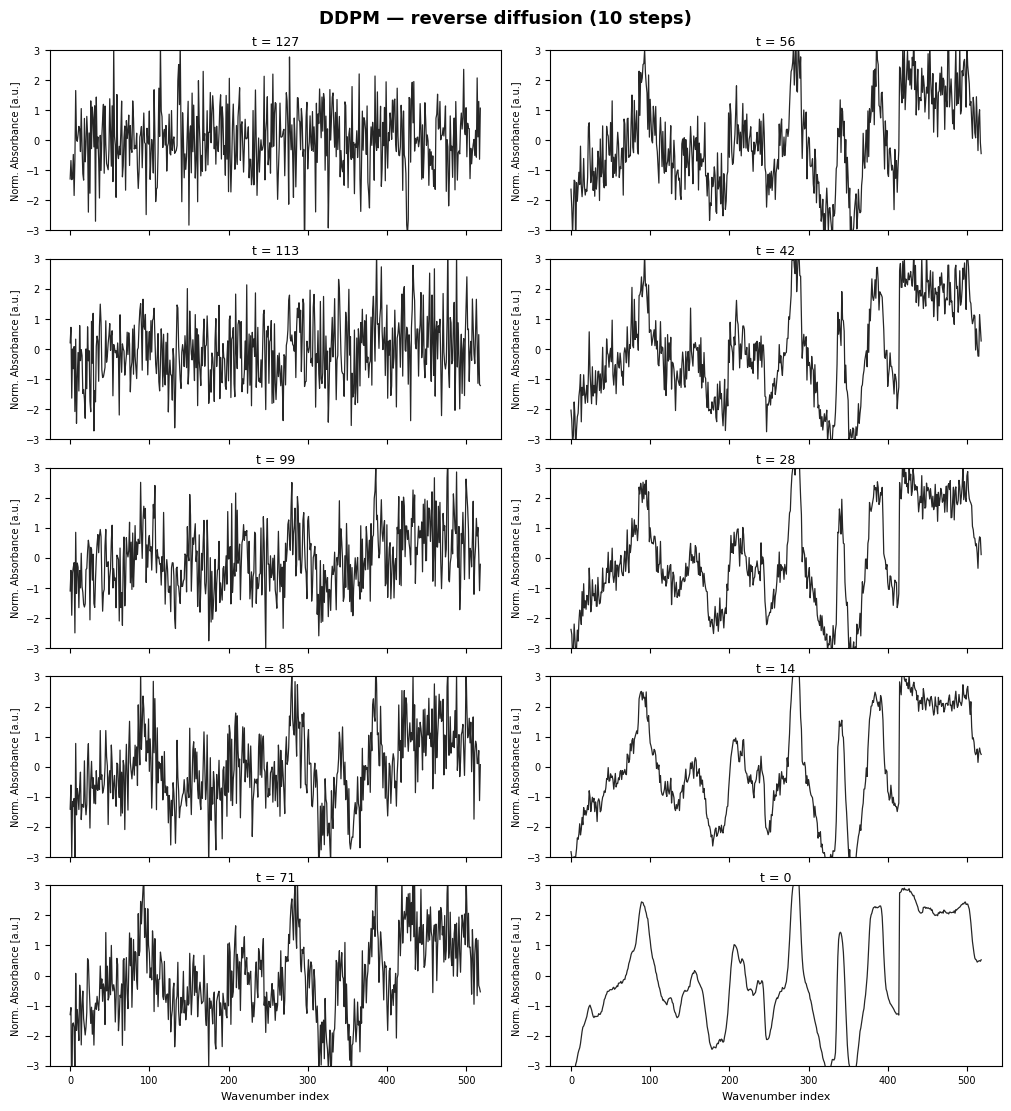

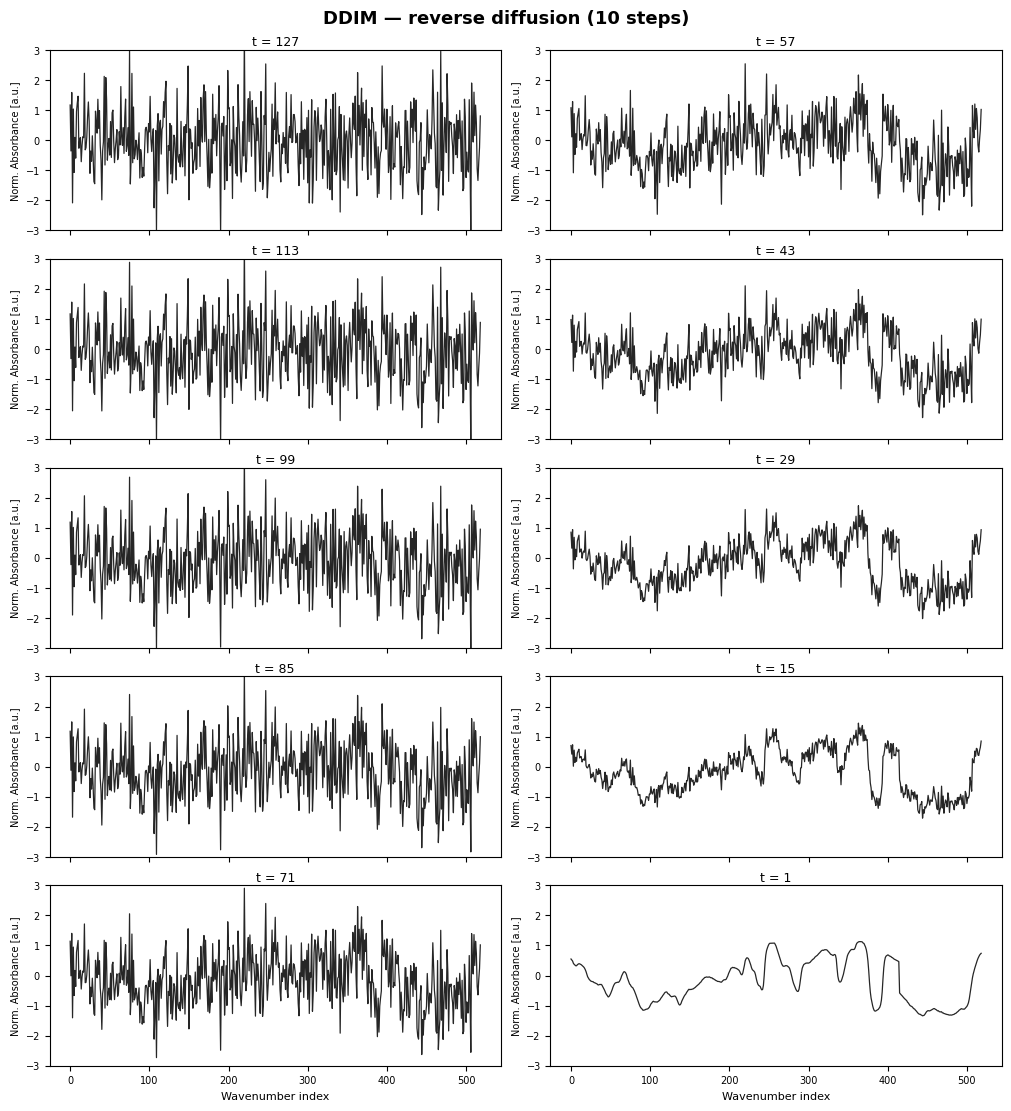

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
GUIDANCE_SCALE      = 1.10
PREDICTION_CLAMP    = None
TIMESTEP_TRUNCATION = 0
TOTAL_T             = len(cdiff.betas)
N_DISPLAY_STEPS     = 10

# ── Helper ────────────────────────────────────────────────────────────────────
def pick_display_indices(timestep_list, n=10):
    total = len(timestep_list)
    pos   = np.round(np.linspace(0, total - 1, n)).astype(int)
    return pos, [timestep_list[p] for p in pos]


# ══════════════════════════════════════════════════════════════════════════════
# 1.  DDPM — collect snapshots
# ══════════════════════════════════════════════════════════════════════════════
ddpm_snapshots = {}

with torch.no_grad(), cdiff.ema.average_parameters():
    gamma = GUIDANCE_SCALE
    B     = len(y_real)
    x     = torch.randn(B, cdiff.cdiff.input_features, device=cdiff.device)

    indices_full = (
        np.array(list(reversed(range(TOTAL_T)))) - TIMESTEP_TRUNCATION
    )
    indices_full = indices_full[indices_full >= 0]

    snap_pos, snap_t = pick_display_indices(list(indices_full))
    snap_t_set       = set(snap_t)

    for t_idx in indices_full:
        t = torch.full((B,), t_idx, device=cdiff.device, dtype=torch.long)

        eps_cond   = cdiff.cdiff.forward(x, y, t)
        eps_uncond = cdiff.cdiff.forward_uncond(x, t)
        eps        = eps_uncond + gamma * (eps_cond - eps_uncond)

        alpha        = cdiff.alphas[t_idx]
        alpha_b      = cdiff.alpha_bar[t_idx]
        alpha_b_prev = cdiff.alpha_bar_prev[t_idx]
        beta         = cdiff.betas[t_idx]

        x0_pred = (x - (1 - alpha_b).sqrt() * eps) / alpha_b.sqrt()
        if PREDICTION_CLAMP is not None:
            x0_pred = torch.clamp(x0_pred, -PREDICTION_CLAMP, PREDICTION_CLAMP)

        mean = (
            (alpha_b_prev.sqrt() * beta / (1 - alpha_b)) * x0_pred
            + (alpha.sqrt() * (1 - alpha_b_prev) / (1 - alpha_b)) * x
        )

        if t_idx in snap_t_set:
            ddpm_snapshots[t_idx] = x.cpu().numpy()[0].copy()
            snap_t_set.discard(t_idx)

        if t_idx > 0:
            beta_tilde = beta * (1 - alpha_b_prev) / (1 - alpha_b)
            x          = mean + beta_tilde.sqrt() * torch.randn_like(x)
        else:
            x = mean

ddpm_ordered  = [ddpm_snapshots[t] for t in snap_t]
ddpm_t_labels = list(snap_t)


# ══════════════════════════════════════════════════════════════════════════════
# 2.  DDIM — collect snapshots
# ══════════════════════════════════════════════════════════════════════════════
ddim_snapshots = {}

with torch.no_grad(), cdiff.ema.average_parameters():
    n_steps   = 64
    eta       = 0.0
    gamma     = GUIDANCE_SCALE
    B         = len(y)
    step_size = TOTAL_T // n_steps
    timesteps = torch.arange(
        TOTAL_T - 1 - TIMESTEP_TRUNCATION, -1, -step_size
    )[:n_steps]

    x = torch.randn(B, cdiff.cdiff.input_features, device=cdiff.device)

    snap_pos_ddim, _ = pick_display_indices(list(range(len(timesteps))))
    snap_pos_set     = set(snap_pos_ddim.tolist())

    for i, t_idx in enumerate(timesteps):
        t = torch.full((B,), t_idx, device=cdiff.device, dtype=torch.long)

        eps_cond   = cdiff.cdiff.forward(x, y, t)
        eps_uncond = cdiff.cdiff.forward_uncond(x, t)
        eps        = eps_uncond + gamma * (eps_cond - eps_uncond)

        ab_t    = cdiff.alpha_bar[t_idx]
        t_prev  = timesteps[i + 1] if i + 1 < len(timesteps) else -1
        ab_prev = (
            cdiff.alpha_bar[t_prev]
            if t_prev >= 0
            else torch.tensor(1.0, device=cdiff.device)
        )

        x0_pred = (x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()
        if PREDICTION_CLAMP is not None:
            x0_pred = torch.clamp(x0_pred, -PREDICTION_CLAMP, PREDICTION_CLAMP)

        sigma  = eta * ((1 - ab_prev) / (1 - ab_t)).sqrt() * (1 - ab_t / ab_prev).sqrt()
        dir_xt = (1 - ab_prev - sigma ** 2).clamp(min=0).sqrt() * eps
        noise  = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)
        x      = ab_prev.sqrt() * x0_pred + dir_xt + sigma * noise

        if i in snap_pos_set:
            ddim_snapshots[i] = (x.cpu().numpy()[0].copy(), int(t_idx.item()))
            snap_pos_set.discard(i)

ddim_ordered  = [ddim_snapshots[p][0] for p in sorted(ddim_snapshots.keys())]
ddim_t_labels = [ddim_snapshots[p][1] for p in sorted(ddim_snapshots.keys())]


# ══════════════════════════════════════════════════════════════════════════════
# 3.  Plotting helper
#     Layout: 5 rows × 2 cols
#     col 0 → display steps 0-4 (noisy end), col 1 → steps 5-9 (clean end)
#     row 0 = first step of that column, row 4 = last step
#     ⇒ top-left  = step 0 (noisiest), bottom-right = step 9 (cleanest)
# ══════════════════════════════════════════════════════════════════════════════
NROWS, NCOLS = 5, 2
YLIM         = (-3, 3)

def make_figure(snapshots, t_labels, method_name, color):
    fig, axes = plt.subplots(
        NROWS, NCOLS,
        figsize=(10, NROWS * 2.2),
        constrained_layout=True,
    )
    fig.suptitle(f"{method_name} — reverse diffusion (10 steps)", fontsize=13, fontweight="bold")

    for display_step in range(N_DISPLAY_STEPS):
        col = display_step // NROWS   # steps 0-4 → col 0, steps 5-9 → col 1
        row = display_step  % NROWS   # position within the column

        ax = axes[row, col]
        ax.plot(snapshots[display_step], color=color, lw=0.9, alpha=0.85)
        ax.set_ylim(YLIM)
        ax.set_title(f"t = {t_labels[display_step]}", fontsize=9, pad=3)
        ax.set_ylabel("Norm. Absorbance [a.u.]", fontsize=7)
        ax.tick_params(labelsize=7)

        # x-axis label only on bottom row of each column
        if row == NROWS - 1:
            ax.set_xlabel("Wavenumber index", fontsize=8)
        else:
            ax.set_xticklabels([])

    return fig


fig_ddpm = make_figure(ddpm_ordered, ddpm_t_labels, "DDPM", color="k")
fig_ddim = make_figure(ddim_ordered, ddim_t_labels, "DDIM", color="k")

fig_ddpm.savefig("ddpm_generation_grid.pdf", dpi=300, bbox_inches="tight")
fig_ddim.savefig("ddim_generation_grid.pdf", dpi=300, bbox_inches="tight")

plt.show()